# 0. Importing Necessary Packages

In [36]:
import numpy as np
import os
from matplotlib import pyplot as plt
from astropy.io import fits
import pandas as pd
from acstools import acszpt
from reproject import reproject_interp

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
%matplotlib inline

# Pandas configuration
pd.set_option('display.max_columns', None)

# Column names for the catalogs
colnames_cat = [
    'id', 'RA', 'Dec', 'x', 'y', 'fwhm', 'area', 'stel', 'ell', 'theta', 'nf5sig', 'nfobs',
    'f435w_mag', 'f435w_magerr', 'f435w_flux', 'f435w_fluxerr', 'f435w_fluxnJy', 'f435w_fluxnJyerr', 'f435w_sig',
    'f606w_mag', 'f606w_magerr', 'f606w_flux', 'f606w_fluxerr', 'f606w_fluxnJy', 'f606w_fluxnJyerr', 'f606w_sig',
    'f814w_mag', 'f814w_magerr', 'f814w_flux', 'f814w_fluxerr', 'f814w_fluxnJy', 'f814w_fluxnJyerr', 'f814w_sig',
    'f105w_mag', 'f105w_magerr', 'f105w_flux', 'f105w_fluxerr', 'f105w_fluxnJy', 'f105w_fluxnJyerr', 'f105w_sig',
    'f125w_mag', 'f125w_magerr', 'f125w_flux', 'f125w_fluxerr', 'f125w_fluxnJy', 'f125w_fluxnJyerr', 'f125w_sig',
    'f140w_mag', 'f140w_magerr', 'f140w_flux', 'f140w_fluxerr', 'f140w_fluxnJy', 'f140w_fluxnJyerr', 'f140w_sig',
    'f160w_mag', 'f160w_magerr', 'f160w_flux', 'f160w_fluxerr', 'f160w_fluxnJy', 'f160w_fluxnJyerr', 'f160w_sig',
    'bright_mag', 'bright_magerr', 'zb', 'zbmin', 'zbmax', 'tb', 'odds', 'chisq', 'chisq2', 'M0', 'zml', 'tml'
]

colnames = [
    'x', 'y', 'num', 'mag_auto', 'merr_auto', 'mag_iso', 'merr_iso', 'mag_iso', 'magerr_iso', 'kron',
    'backgr', 'ra', 'dec', 'a', 'b', 'theta', 'mu0', 'flag', 'fwhm', 'flxrad', 'cl'
]

bands = ["F105W", "F160W"]
bands_catread = ["f105w", "f160w"]

# Read primary catalog
dat_cat = np.genfromtxt(
    '../DATA/hlsp_relics_hst_wfc3ir_smacs0723m73_multi_v1_cat.txt',
    dtype=None, encoding='ascii', names=colnames_cat
)

# Read image catalogs for both bands
dat_0 = np.genfromtxt(
    f'../RESULT/60mas/F105W-F160W/Threshold_low/{bands[0]}.cat',
    dtype=None, encoding='ascii', names=colnames
)
dat_1 = np.genfromtxt(
    f'../RESULT/60mas/F105W-F160W/Threshold_low/{bands[1]}.cat',
    dtype=None, encoding='ascii', names=colnames
)


# 0. Galactic Extinction in Magnitudes

## magnitude correction

In [37]:
A_lambda = [1.015, 0.470]
EBV = 0.1893

Extmag = [A * EBV for A in A_lambda]

dat_0['mag_iso'] = dat_0['mag_iso'] - Extmag[0]
dat_1['mag_iso'] = dat_1['mag_iso'] - Extmag[1]

# 1. Raw-Data Plot

## 1) RA/dec

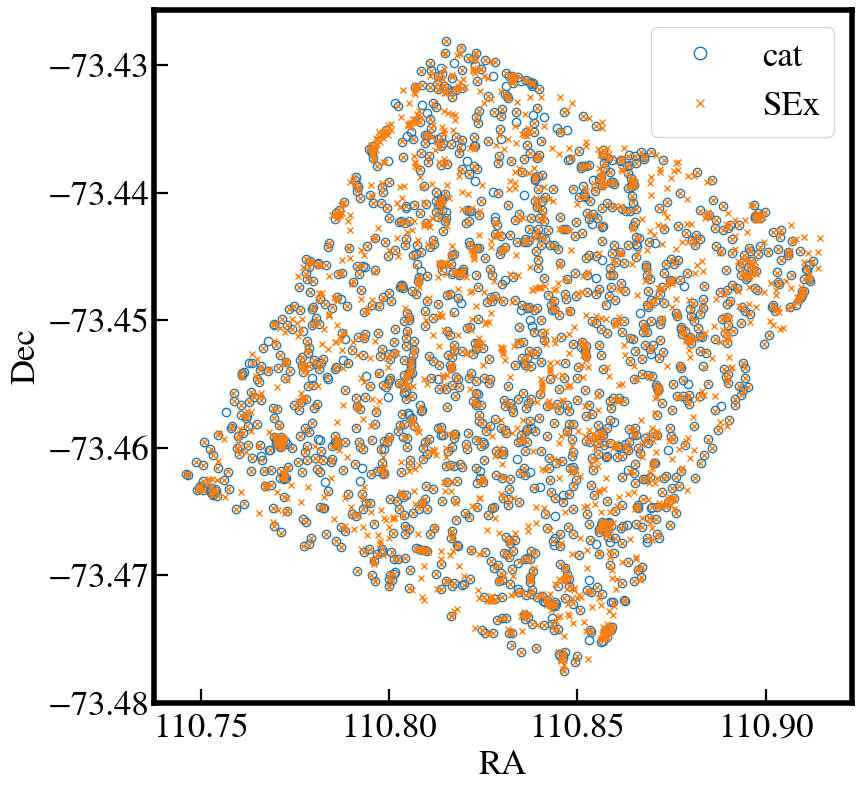

In [38]:
fig, ax = plt.subplots(figsize=(9, 9))

# 'cat' - 뚫린 동그라미 (open circle)
ax.plot(dat_cat['RA'], dat_cat['Dec'], marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')

# 'SEx' - x 마커
ax.plot(dat_0['ra'], dat_0['dec'], marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
legend = ax.legend(markerscale=1.5)
plt.show()

## 2) Mag-Magerr Plot

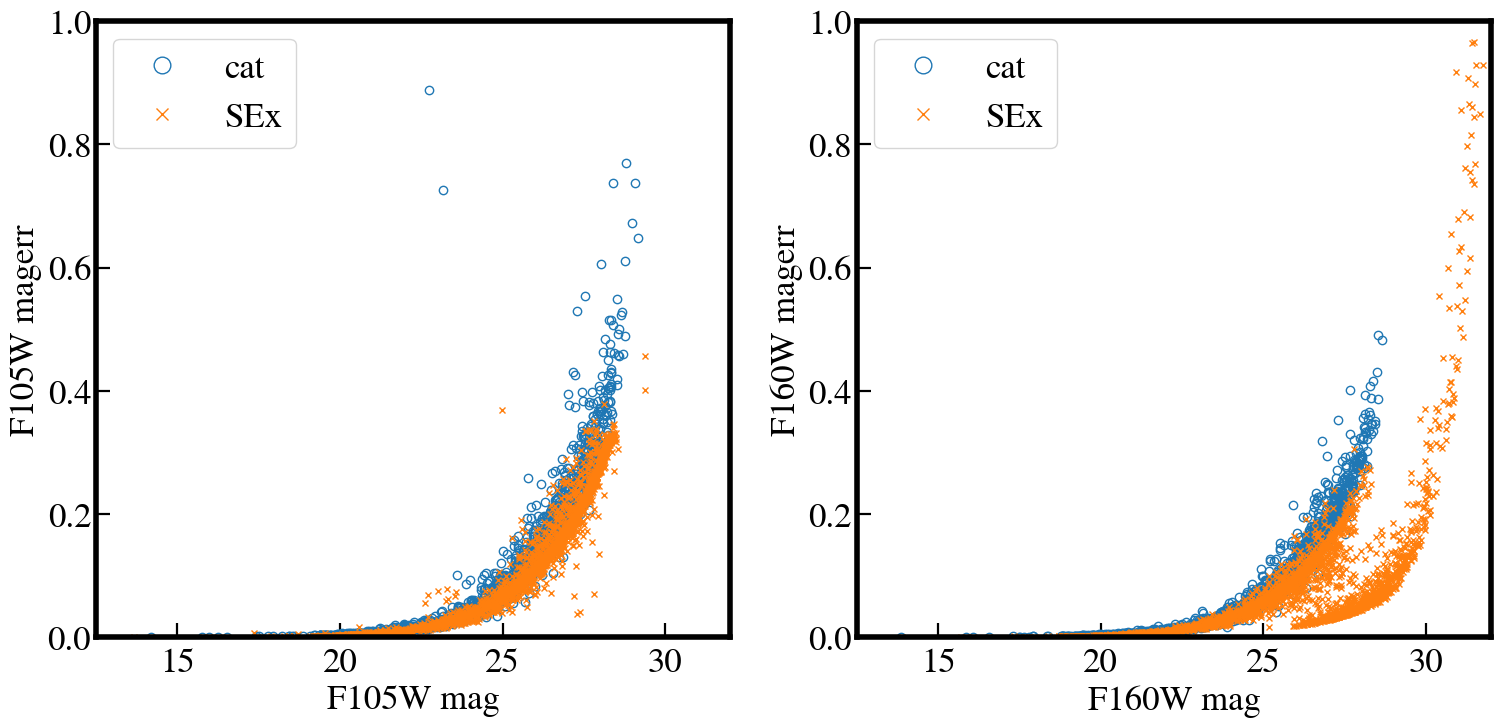

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(18,8))
mag_range = (dat_0['mag_iso'] < 99.0) & (dat_1['mag_iso'] < 99.0)
# magnitude of 99.0 means the source not detected in the bluer-band image but detected in the redder-band image.

# 'cat' - blue open circle
ax[0].plot(dat_cat[f'{bands_catread[0]}_mag'], dat_cat[f'{bands_catread[0]}_magerr'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
# 'SEx' - orange x
ax[0].plot(dat_0['mag_iso'][mag_range], dat_0['magerr_iso'][mag_range],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0].set_xlim([12.5, 32])
ax[0].set_ylim([0.0, 1.0])
ax[0].set_xlabel(f'{bands[0]} mag')
ax[0].set_ylabel(f'{bands[0]} magerr')

# 'cat' - blue open circle
ax[1].plot(dat_cat[f'{bands_catread[1]}_mag'], dat_cat[f'{bands_catread[1]}_magerr'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
# 'SEx' - orange x
ax[1].plot(dat_1['mag_iso'][mag_range], dat_1['magerr_iso'][mag_range],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1].set_xlim([12.5, 32])
ax[1].set_ylim([0, 1])
ax[1].set_xlabel(f'{bands[1]} mag')
ax[1].set_ylabel(f'{bands[1]} magerr')

# --- Modern legend API: change marker size with handler_map in legend() ---
from matplotlib.legend_handler import HandlerLine2D

handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

lgnd0 = ax[0].legend(markerscale=2, handler_map=handler_map)
lgnd1 = ax[1].legend(markerscale=2, handler_map=handler_map)

## 3) Magnitude - stellarity (``CLASS_STAR``) digram

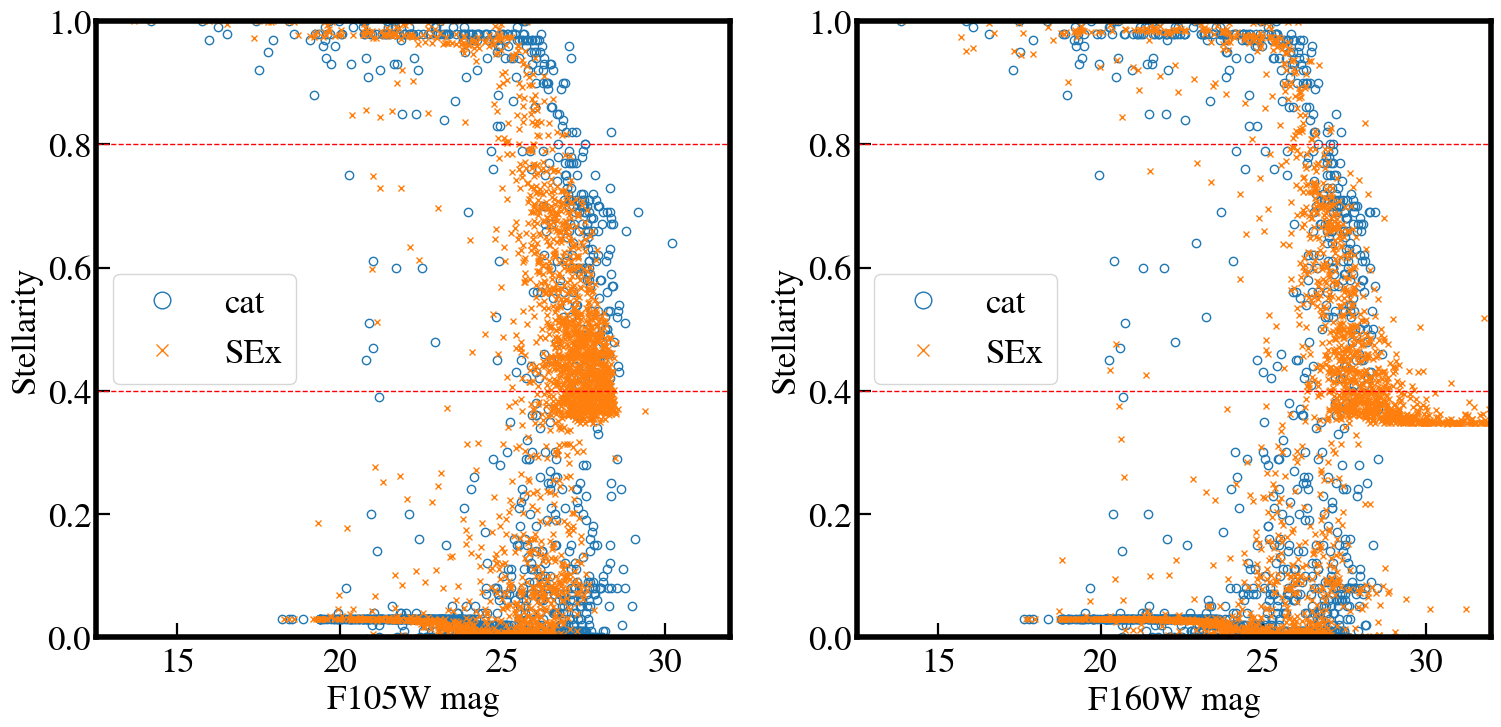

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(18,8))
mag_range = (dat_0['mag_iso'] < 99.0) & (dat_1['mag_iso'] < 99.0)
# magnitude of 99.0 means the source not detected in the bluer-band image but detected in the redder-band image.

# 'cat' - blue open circle
ax[0].plot(dat_cat[f'{bands_catread[0]}_mag'], dat_cat['stel'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
# 'SEx' - orange x
ax[0].plot(dat_0['mag_iso'][mag_range], dat_0['cl'][mag_range],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0].set_xlim([12.5, 32])
ax[0].set_ylim([0.0, 1.0])
ax[0].set_xlabel(f'{bands[0]} mag')
ax[0].set_ylabel('Stellarity')
ax[0].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[0].axhline(0.8, 0, 1, color='red', ls='--', lw=1)

# 'cat' - blue open circle
ax[1].plot(dat_cat[f'{bands_catread[1]}_mag'], dat_cat['stel'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
# 'SEx' - orange x
ax[1].plot(dat_1['mag_iso'][mag_range], dat_1['cl'][mag_range],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1].set_xlim([12.5, 32])
ax[1].set_ylim([0, 1])
ax[1].set_xlabel(f'{bands[1]} mag')
ax[1].set_ylabel('Stellarity')
ax[1].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[1].axhline(0.8, 0, 1, color='red', ls='--', lw=1)

# --- Modern legend API ---
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}
lgnd0 = ax[0].legend(markerscale=2, handler_map=handler_map)
lgnd1 = ax[1].legend(markerscale=2, handler_map=handler_map)

## 4) CMD

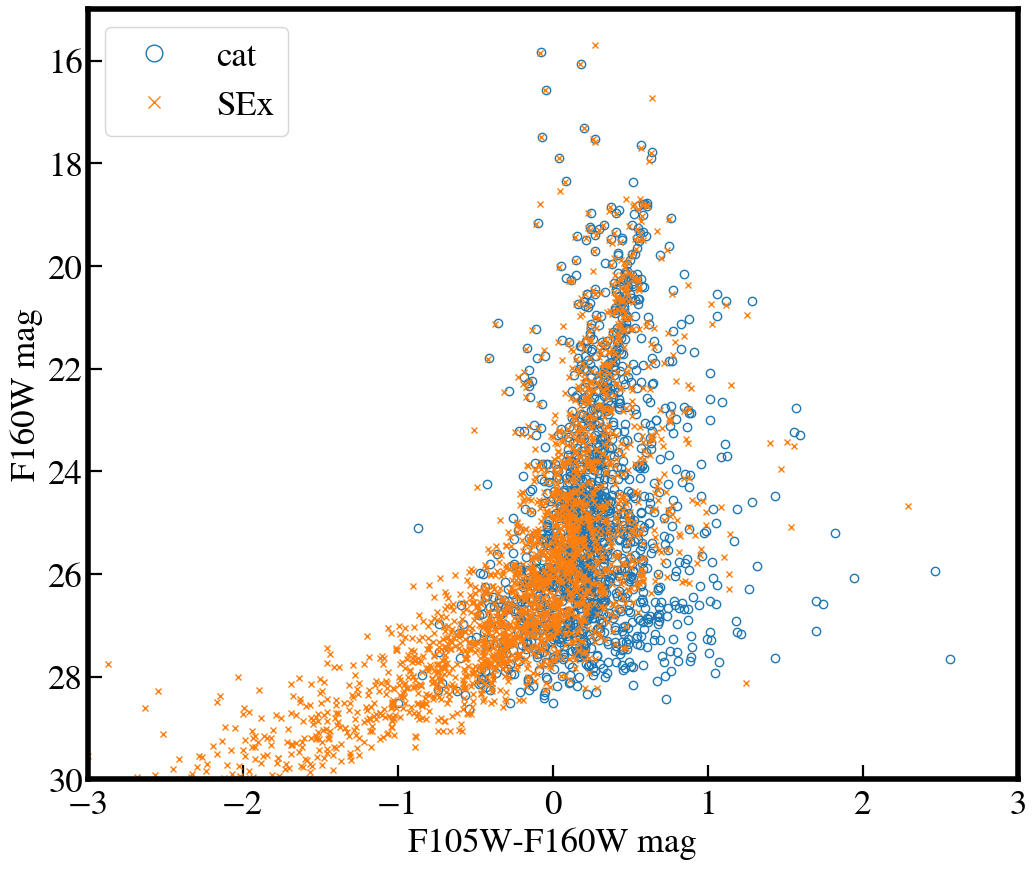

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
galcnd = (dat_0['mag_iso'] < 99.0) & (dat_1['mag_iso'] < 99.0)
# magnitude of 99.0 means the source not detected in the bluer-band image but detected in the redder-band image.

# 'cat' - blue open circle
ax.plot(dat_cat[f'{bands_catread[0]}_mag'] - dat_cat[f'{bands_catread[1]}_mag'], 
        dat_cat[f'{bands_catread[1]}_mag'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
# 'SEx' - orange x
ax.plot(dat_0['mag_iso'][galcnd] - dat_1['mag_iso'][galcnd], 
        dat_1['mag_iso'][galcnd],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax.set_ylabel(f'{bands[1]} mag')

# --- Modern legend API ---
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}
lgnd0 = ax.legend(markerscale=2, handler_map=handler_map)

# 2. Catalog - Sextractor Matching

In [44]:
# Catalog-SEx matching utilities

from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as u

# --- Simple catalog-to-SExtractor coordinate matching (fixed 0.1 arcsec tolerance) ---
ra_sex, dec_sex = dat_0['ra'], dat_0['dec']
ra_cat, dec_cat = dat_cat['RA'], dat_cat['Dec']

tolerance = 0.1 / 3600.0  # 0.1 arcsec in degrees
coords_sex = SkyCoord(ra=ra_sex * u.deg, dec=dec_sex * u.deg)
coords_cat = SkyCoord(ra=ra_cat * u.deg, dec=dec_cat * u.deg)

idx, sep2d, _ = match_coordinates_sky(coords_sex, coords_cat, nthneighbor=1, storekdtree='kdtree_sky')
matched_mask = sep2d.degree < tolerance

n_matched = np.count_nonzero(matched_mask)
idx_cat = idx[matched_mask]
idx_sex = np.where(matched_mask)[0]

# --- Convenient class for catalog-SEx matching ---
class MatchSexCat:
    def __init__(self, dat_sex, dat_cat, tolerance_arcsec=0.05):
        tol = tolerance_arcsec / 3600.0
        ra_s, dec_s = dat_sex['ra'], dat_sex['dec']
        ra_c, dec_c = dat_cat['RA'], dat_cat['Dec']
        src_coords = SkyCoord(ra=ra_s * u.deg, dec=dec_s * u.deg)
        cat_coords = SkyCoord(ra=ra_c * u.deg, dec=dec_c * u.deg)
        idx, sep2d, _ = match_coordinates_sky(src_coords, cat_coords, nthneighbor=1, storekdtree='kdtree_sky')
        matched = sep2d.degree < tol
        self.idx_cat = idx[matched]
        self.idx_sex = np.where(matched)[0]
        self.n_matched = len(self.idx_cat)

    def matched_sex(self, dat_sex):
        return dat_sex[self.idx_sex]

    def matched_sex_indices(self):
        return self.idx_sex

    def matched_cat(self, dat_cat):
        return dat_cat[self.idx_cat]

    def matched_cat_indices(self):
        return self.idx_cat

    def matched_count(self):
        return self.n_matched



## 1) Plot of Matched Source and Detected Source

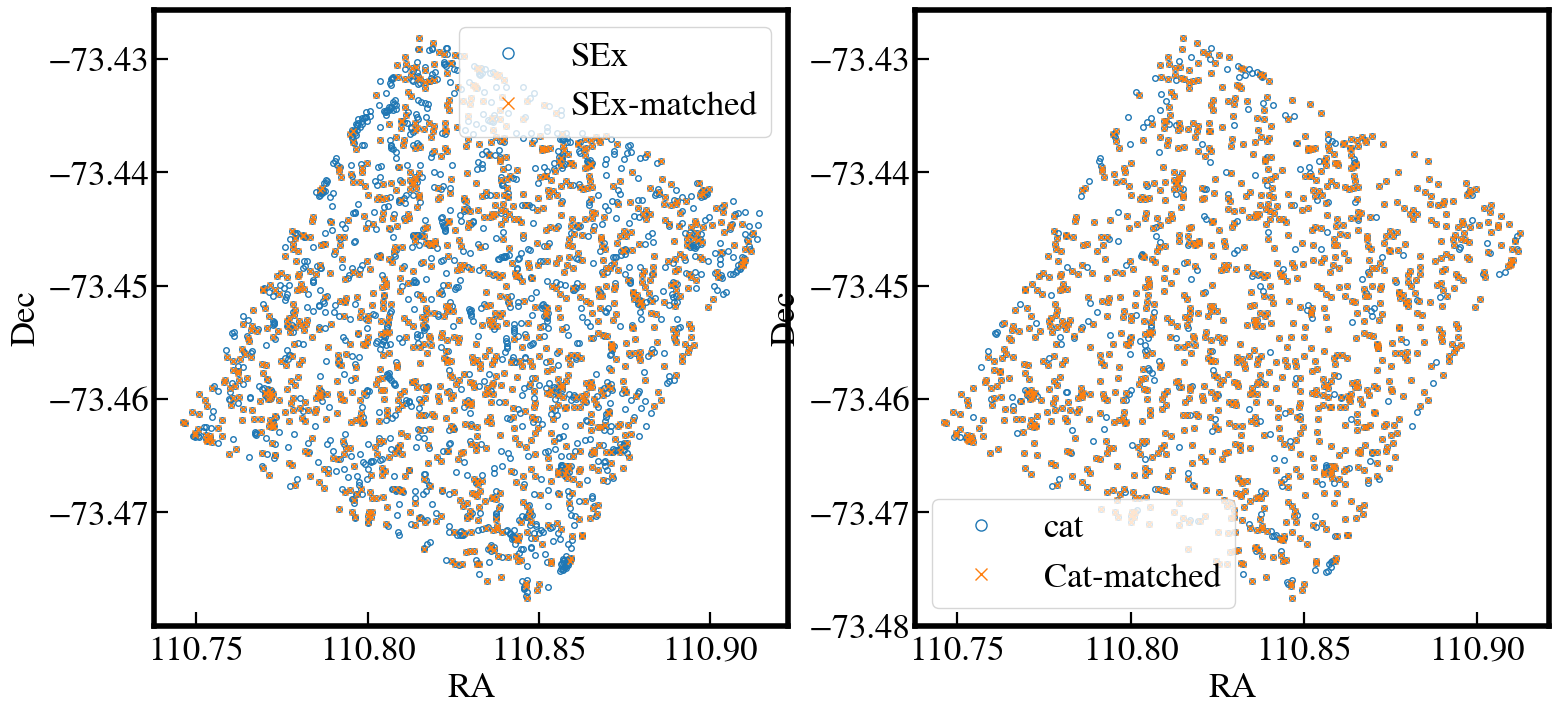

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: SExtractor sources
ax[0].plot(dat_0['ra'], dat_0['dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx')
ax[0].plot(dat_0[idx_sex]['ra'], dat_0[idx_sex]['dec'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx-matched')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('Dec')

# Right panel: Catalog sources
ax[1].plot(dat_cat['RA'], dat_cat['Dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[1].plot(dat_cat[idx_cat]['RA'], dat_cat[idx_cat]['Dec'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='Cat-matched')
ax[1].set_xlabel('RA')
ax[1].set_ylabel('Dec')

# --- Modern legend API ---
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}
lgnd0 = ax[0].legend(markerscale=2, handler_map=handler_map)
lgnd1 = ax[1].legend(markerscale=2, handler_map=handler_map)


## 2) Drawing Plot Again with Matching INDEX

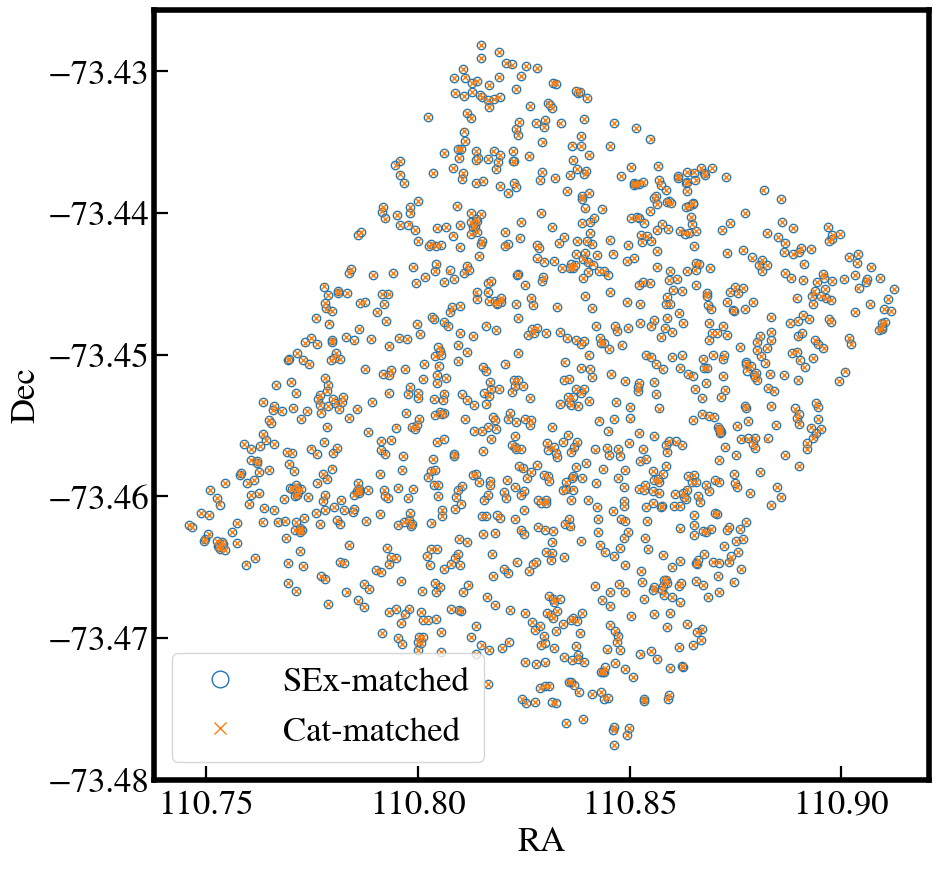

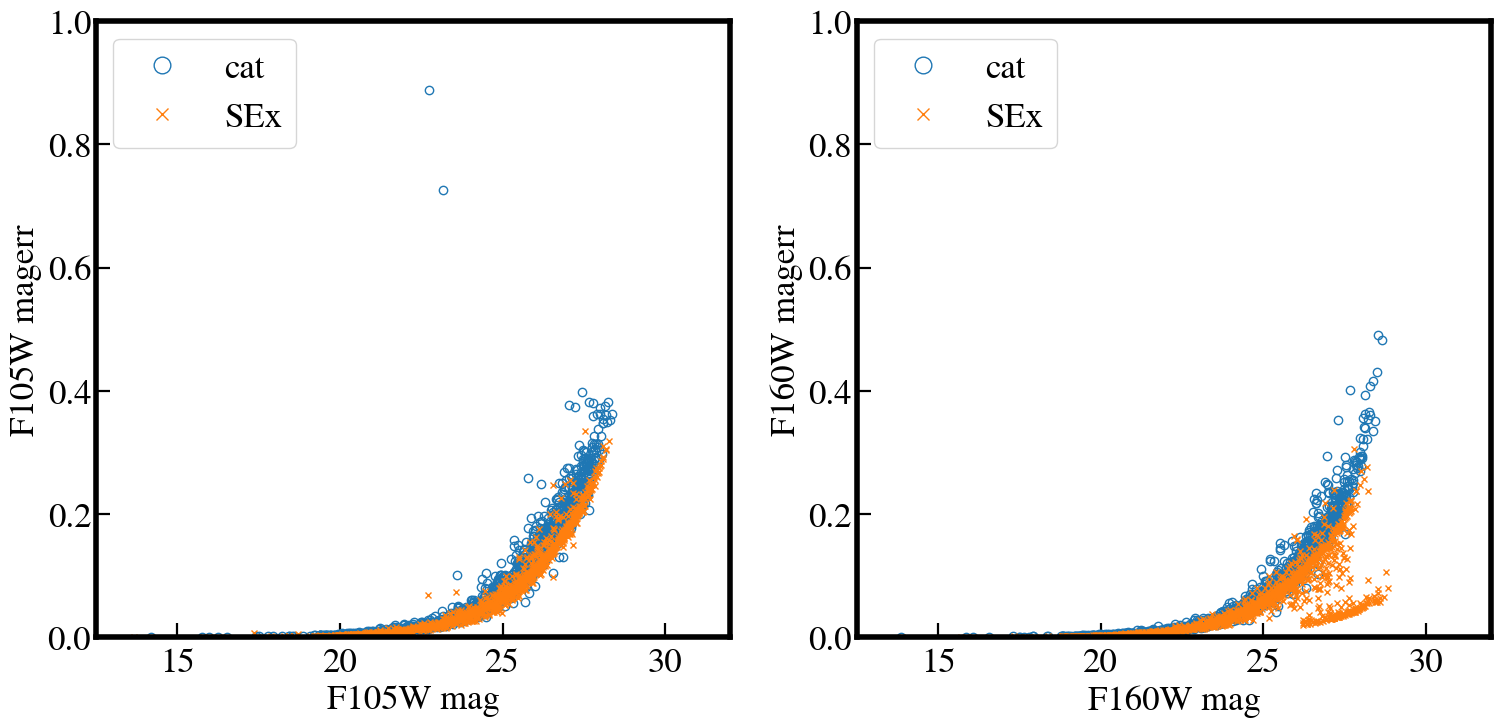

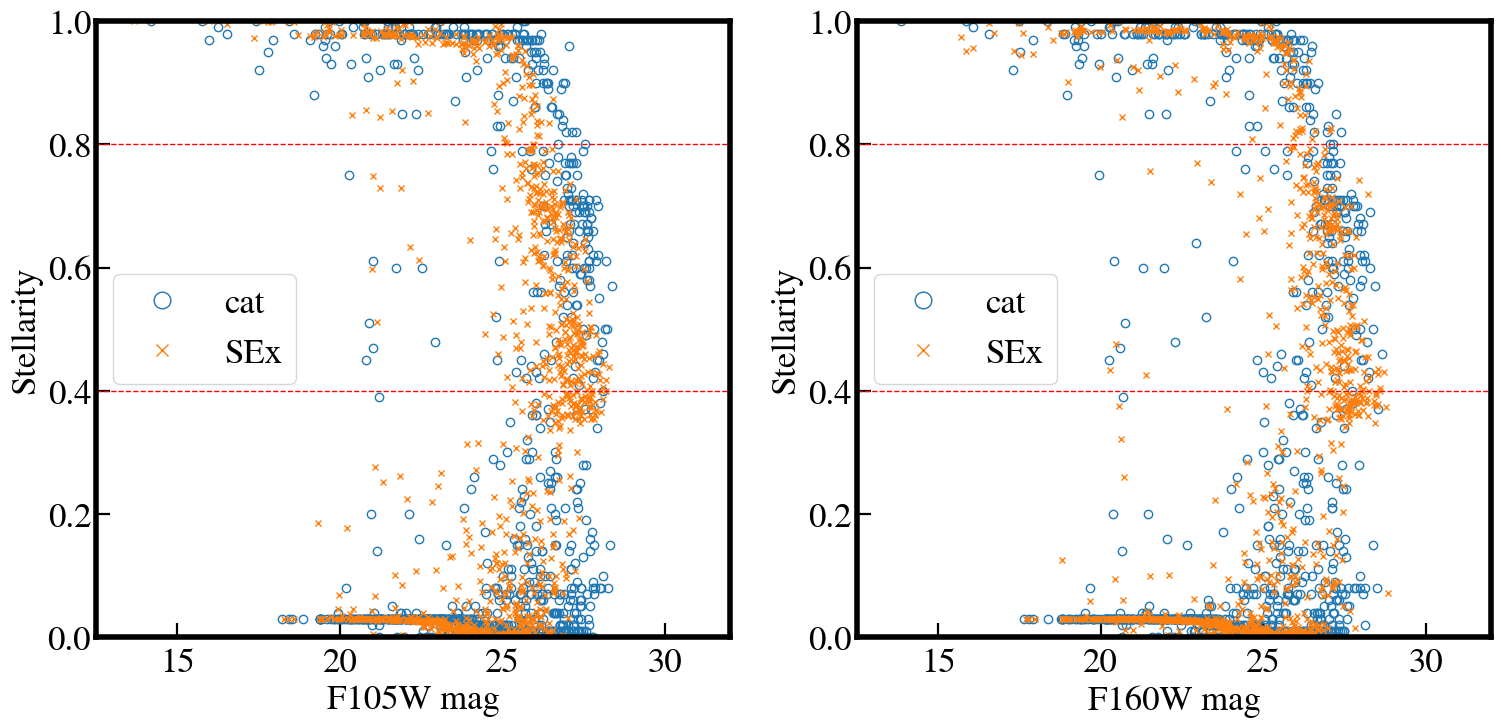

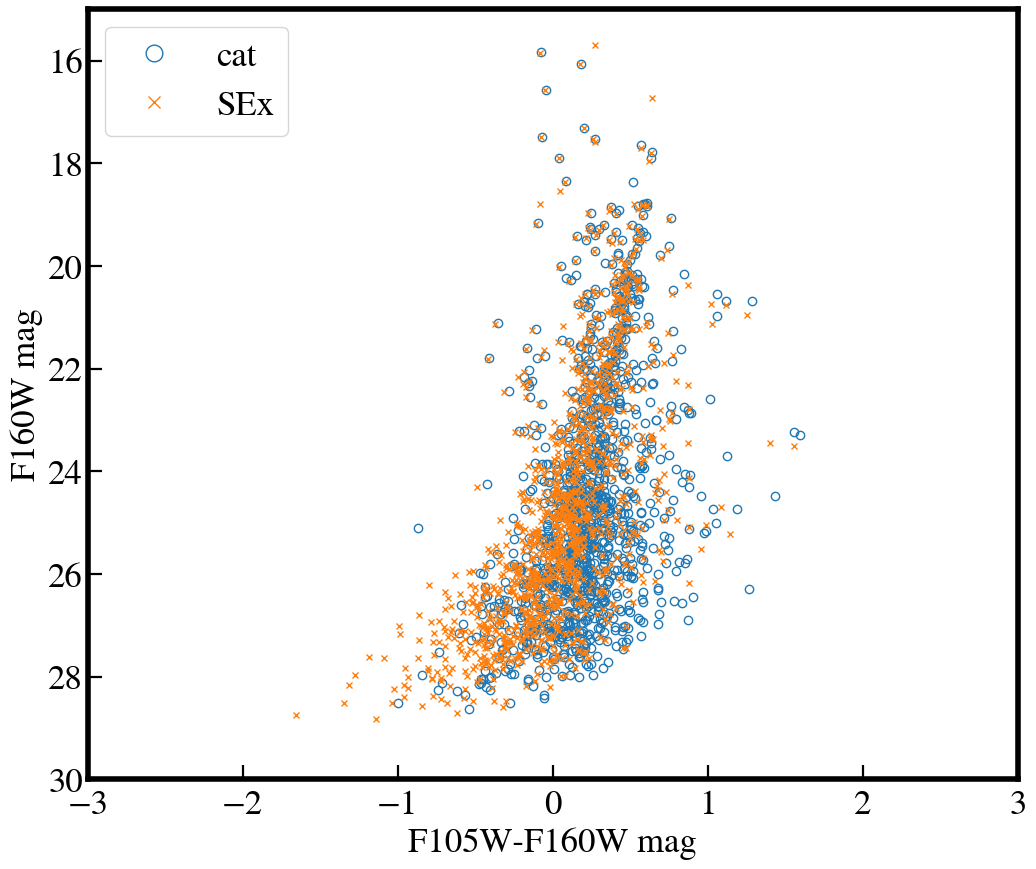

In [50]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Plot 1: Matched Sources RA/Dec
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(dat_0[idx_sex]['ra'], dat_0[idx_sex]['dec'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='SEx-matched')
ax.plot(dat_cat[idx_cat]['RA'], dat_cat[idx_cat]['Dec'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='Cat-matched')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.legend(markerscale=2, handler_map=handler_map)
plt.show()

# =============================================================================
# Plot 2: Matched Sources Mag-MagErr
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel
ax[0].plot(dat_cat[idx_cat][f'{bands_catread[0]}_mag'], dat_cat[idx_cat][f'{bands_catread[0]}_magerr'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[0].plot(dat_0[idx_sex]['mag_iso'], dat_0[idx_sex]['magerr_iso'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0].set_xlim([12.5, 32])
ax[0].set_ylim([0.0, 1.0])
ax[0].set_xlabel(f'{bands[0]} mag')
ax[0].set_ylabel(f'{bands[0]} magerr')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel
ax[1].plot(dat_cat[idx_cat][f'{bands_catread[1]}_mag'], dat_cat[idx_cat][f'{bands_catread[1]}_magerr'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[1].plot(dat_1[idx_sex]['mag_iso'], dat_1[idx_sex]['magerr_iso'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1].set_xlim([12.5, 32])
ax[1].set_ylim([0, 1])
ax[1].set_xlabel(f'{bands[1]} mag')
ax[1].set_ylabel(f'{bands[1]} magerr')
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()

# =============================================================================
# Plot 3: Matched Sources Mag-Stellarity
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel
ax[0].plot(dat_cat[idx_cat][f'{bands_catread[0]}_mag'], dat_cat[idx_cat]['stel'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[0].plot(dat_0[idx_sex]['mag_iso'], dat_0[idx_sex]['cl'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0].set_xlim([12.5, 32])
ax[0].set_ylim([0.0, 1.0])
ax[0].set_xlabel(f'{bands[0]} mag')
ax[0].set_ylabel('Stellarity')
ax[0].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[0].axhline(0.8, 0, 1, color='red', ls='--', lw=1)
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel
ax[1].plot(dat_cat[idx_cat][f'{bands_catread[1]}_mag'], dat_cat[idx_cat]['stel'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[1].plot(dat_1[idx_sex]['mag_iso'], dat_1[idx_sex]['cl'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1].set_xlim([12.5, 32])
ax[1].set_ylim([0, 1])
ax[1].set_xlabel(f'{bands[1]} mag')
ax[1].set_ylabel('Stellarity')
ax[1].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[1].axhline(0.8, 0, 1, color='red', ls='--', lw=1)
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()

# =============================================================================
# Plot 4: Matched Sources CMD
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

ax.plot(dat_cat[idx_cat][f'{bands_catread[0]}_mag'] - dat_cat[idx_cat][f'{bands_catread[1]}_mag'],
        dat_cat[idx_cat][f'{bands_catread[1]}_mag'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax.plot(dat_0[idx_sex]['mag_iso'] - dat_1[idx_sex]['mag_iso'],
        dat_1[idx_sex]['mag_iso'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax.set_ylabel(f'{bands[1]} mag')
ax.legend(markerscale=2, handler_map=handler_map)
plt.show()


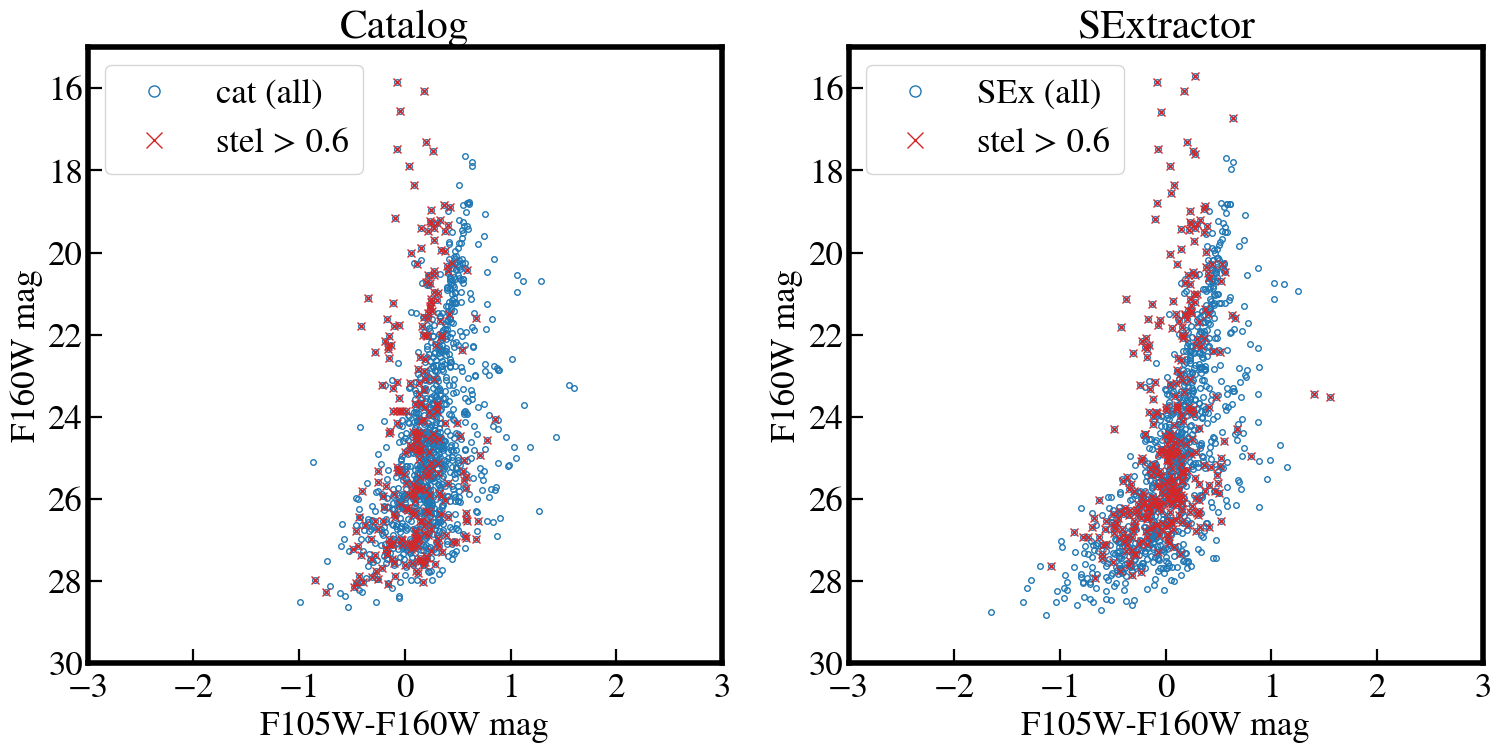

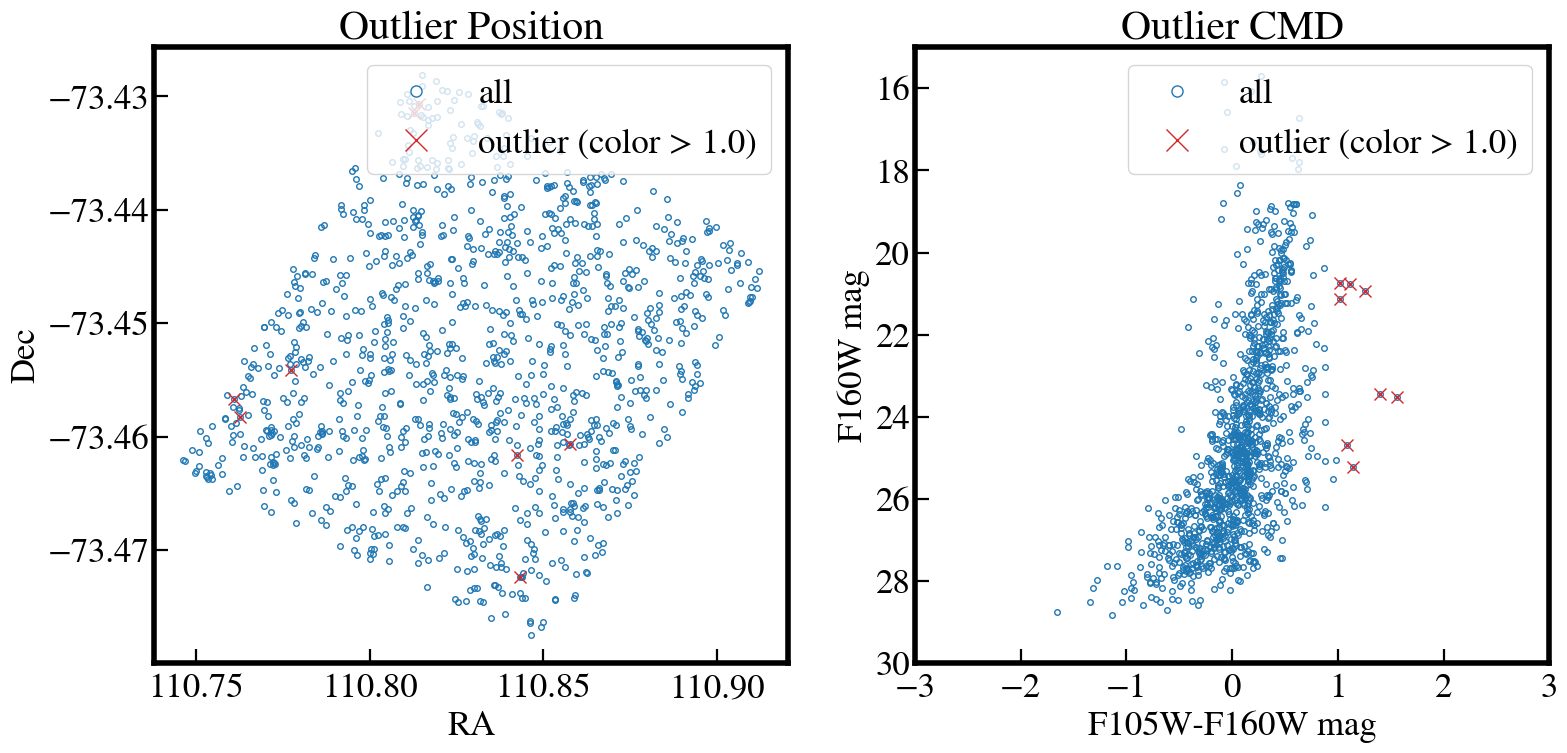

In [51]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Plot 1: CMD with Stellarity Filter (stel > 0.6)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Data preparation
mag_cat_0 = dat_cat[idx_cat][f'{bands_catread[0]}_mag']
mag_cat_1 = dat_cat[idx_cat][f'{bands_catread[1]}_mag']
mag_src_0 = dat_0[idx_sex]['mag_iso']
mag_src_1 = dat_1[idx_sex]['mag_iso']

# Stellarity filter (stel > 0.6 = likely stars)
stelf_cat = dat_cat[idx_cat]['stel'] > 0.6
stelf_src = dat_0[idx_sex]['cl'] > 0.6

# Left panel: Catalog CMD
ax[0].plot(mag_cat_0 - mag_cat_1, mag_cat_1,
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat (all)')
ax[0].plot(mag_cat_0[stelf_cat] - mag_cat_1[stelf_cat], mag_cat_1[stelf_cat],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[0].set_xlim([-3, 3])
ax[0].set_ylim([30, 15])
ax[0].set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax[0].set_ylabel(f'{bands[1]} mag')
ax[0].set_title('Catalog')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: SExtractor CMD
ax[1].plot(mag_src_0 - mag_src_1, mag_src_1,
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx (all)')
ax[1].plot(mag_src_0[stelf_src] - mag_src_1[stelf_src], mag_src_1[stelf_src],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[1].set_xlim([-3, 3])
ax[1].set_ylim([30, 15])
ax[1].set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax[1].set_ylabel(f'{bands[1]} mag')
ax[1].set_title('SExtractor')
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()

# =============================================================================
# Plot 2: Outlier Analysis (color > 1.0)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Data preparation
ra_src = dat_0[idx_sex]['ra']
dec_src = dat_0[idx_sex]['dec']

# Outlier filter: sources with color > 1.0 mag
outlier_mask = (mag_src_0 - mag_src_1) > 1.0

# Left panel: RA/Dec with outliers highlighted
ax[0].plot(ra_src, dec_src,
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='all')
ax[0].plot(ra_src[outlier_mask], dec_src[outlier_mask],
           marker='x', ms=8, color='tab:red', linestyle='None', label='outlier (color > 1.0)')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('Dec')
ax[0].set_title('Outlier Position')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: CMD with outliers highlighted
ax[1].plot(mag_src_0 - mag_src_1, mag_src_1,
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='all')
ax[1].plot(mag_src_0[outlier_mask] - mag_src_1[outlier_mask], mag_src_1[outlier_mask],
           marker='x', ms=8, color='tab:red', linestyle='None', label='outlier (color > 1.0)')
ax[1].set_xlim([-3, 3])
ax[1].set_ylim([30, 15])
ax[1].set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax[1].set_ylabel(f'{bands[1]} mag')
ax[1].set_title('Outlier CMD')
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()


## 3) Error Estimation / Parameter Estimation

### (1) Matching Magnitude - Reference Magnitude Error --> thresh problem ? or zp? 


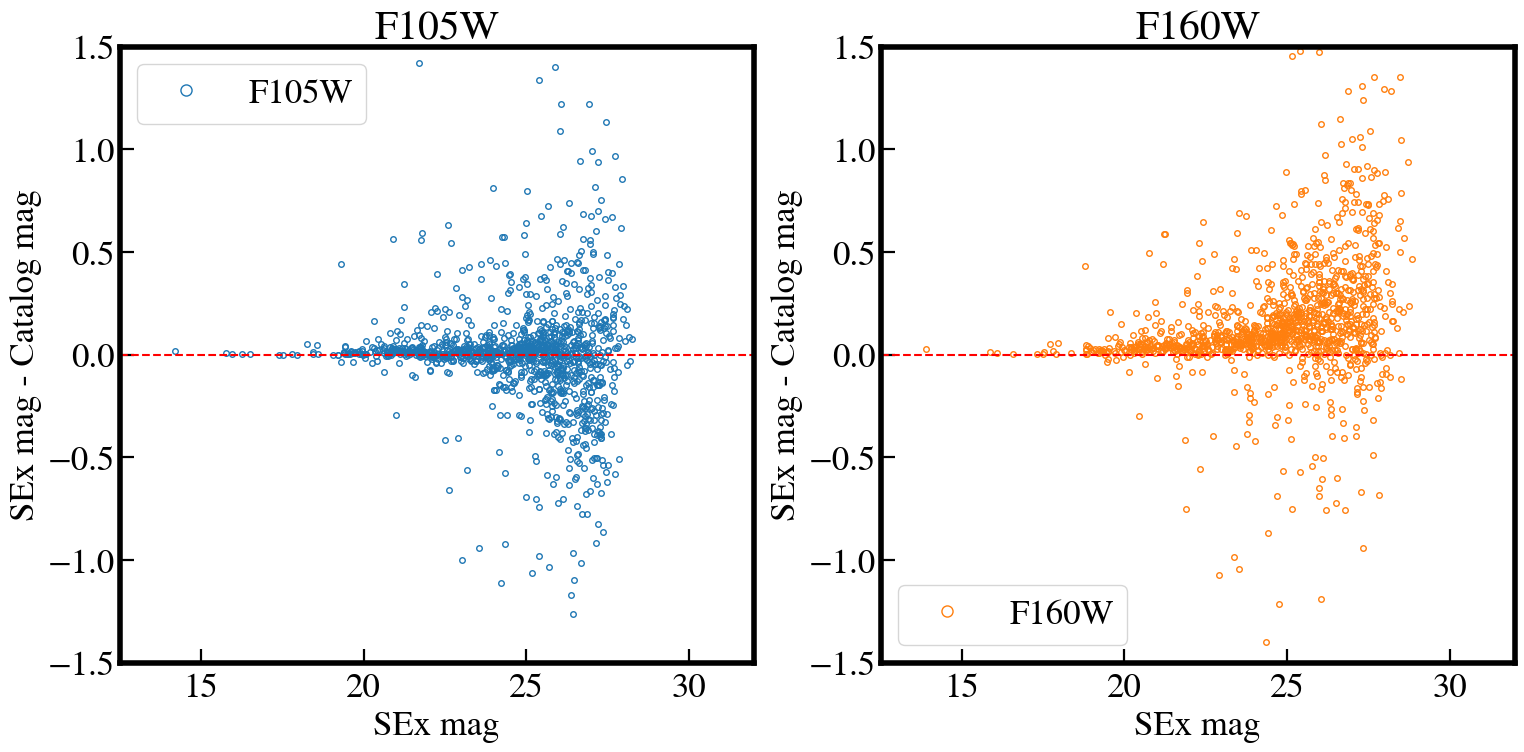

In [52]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Magnitude Comparison: SExtractor vs Catalog
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: F105W
ax[0].plot(dat_0[idx_sex]['mag_iso'], 
           dat_0[idx_sex]['mag_iso'] - dat_cat[idx_cat][f'{bands_catread[0]}_mag'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0].axhline(0, ls='--', color='red', lw=1.5)
ax[0].set_xlim([12.5, 32])
ax[0].set_ylim([-1.5, 1.5])
ax[0].set_xlabel('SEx mag')
ax[0].set_ylabel('SEx mag - Catalog mag')
ax[0].set_title(bands[0])
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: F160W
ax[1].plot(dat_1[idx_sex]['mag_iso'], 
           dat_1[idx_sex]['mag_iso'] - dat_cat[idx_cat][f'{bands_catread[1]}_mag'],
           marker='o', ms=4, mfc='none', mec='tab:orange', linestyle='None', label=bands[1])
ax[1].axhline(0, ls='--', color='red', lw=1.5)
ax[1].set_xlim([12.5, 32])
ax[1].set_ylim([-1.5, 1.5])
ax[1].set_xlabel('SEx mag')
ax[1].set_ylabel('SEx mag - Catalog mag')
ax[1].set_title(bands[1])
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()


### (2) FWHM Estimation 

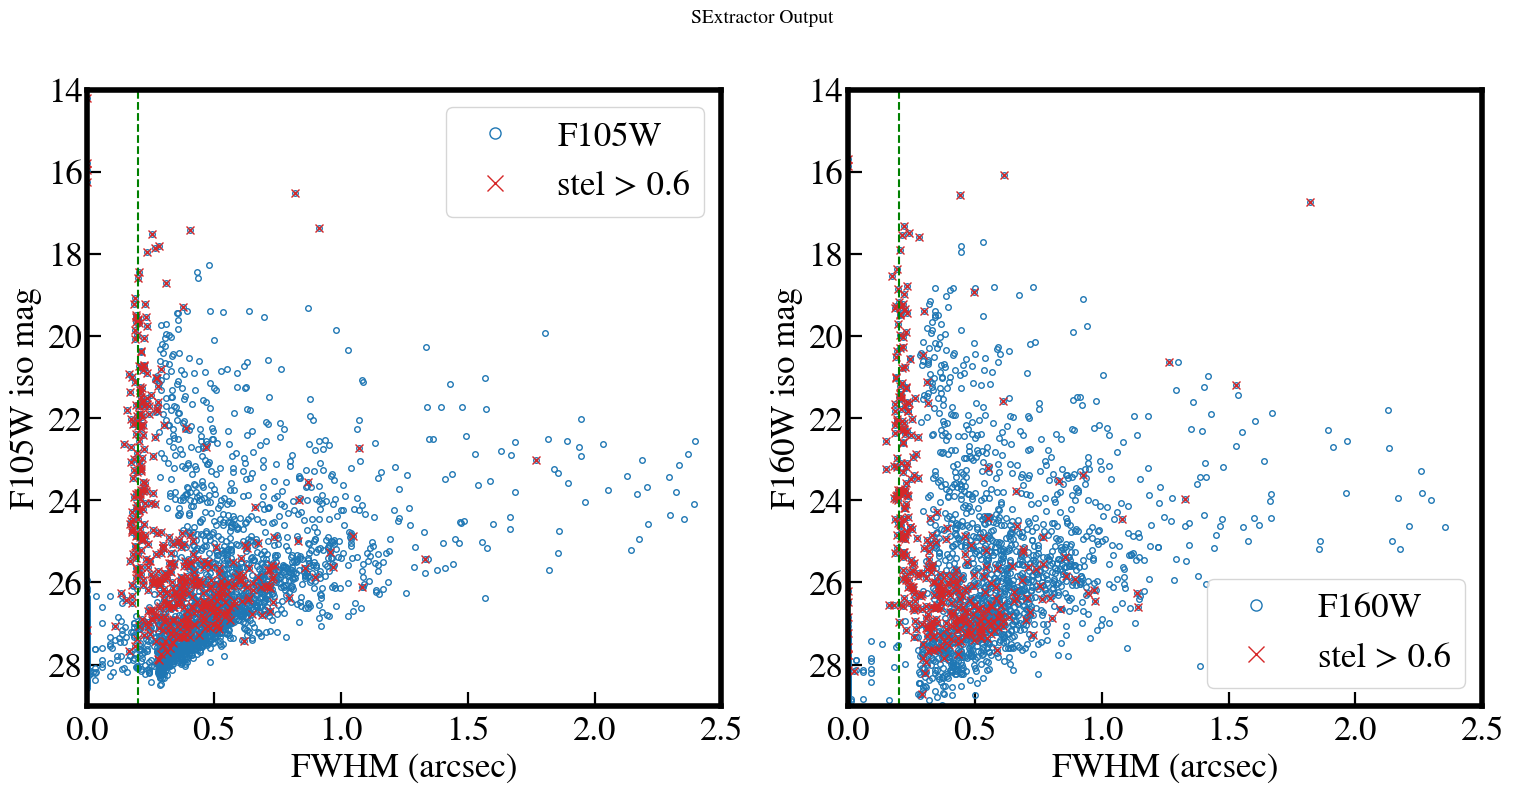

In [53]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# FWHM Estimation: SExtractor Output
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SExtractor Output', fontsize=14)

pixel_scale = 0.06  # arcsec/pixel

# Stellarity filter (stel > 0.6 = likely point sources)
pointsource_0 = dat_0['cl'] > 0.6
pointsource_1 = dat_1['cl'] > 0.6

# Left panel: F105W
ax[0].plot(dat_0['fwhm'] * pixel_scale, dat_0['mag_iso'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0].plot(dat_0['fwhm'][pointsource_0] * pixel_scale, dat_0['mag_iso'][pointsource_0],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[0].axvline(0.2, ls='--', color='green', lw=1.5)
ax[0].set_xlim([0, 2.5])
ax[0].set_ylim([29, 14])
ax[0].set_xlabel('FWHM (arcsec)')
ax[0].set_ylabel(f'{bands[0]} iso mag')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: F160W
ax[1].plot(dat_1['fwhm'] * pixel_scale, dat_1['mag_iso'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[1])
ax[1].plot(dat_1['fwhm'][pointsource_1] * pixel_scale, dat_1['mag_iso'][pointsource_1],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[1].axvline(0.2, ls='--', color='green', lw=1.5)
ax[1].set_xlim([0, 2.5])
ax[1].set_ylim([29, 14])
ax[1].set_xlabel('FWHM (arcsec)')
ax[1].set_ylabel(f'{bands[1]} iso mag')
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()


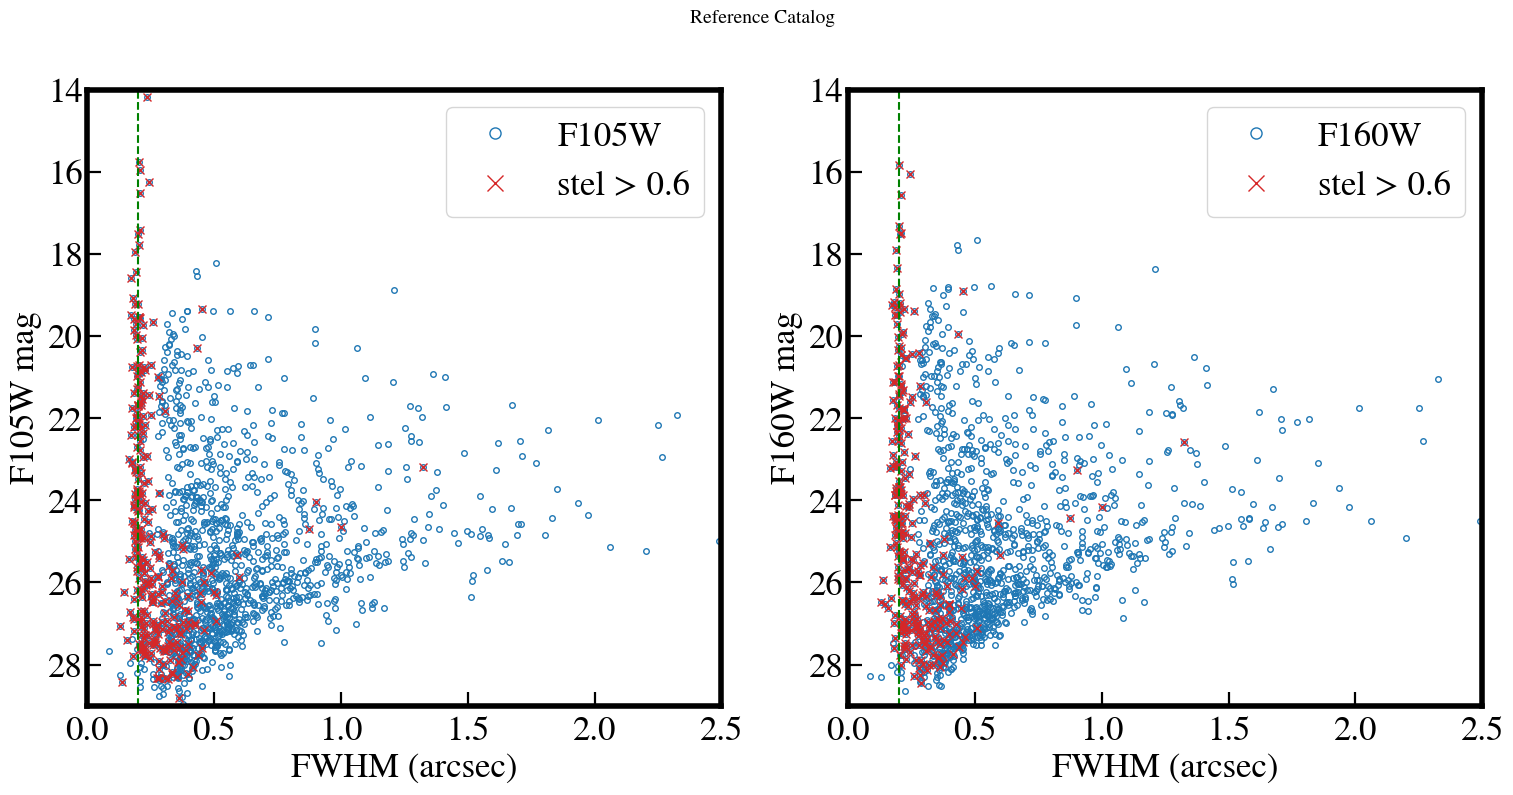

In [54]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# FWHM Estimation: Reference Catalog
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Reference Catalog', fontsize=14)

# Stellarity filter (stel > 0.6 = likely point sources)
pointsource = dat_cat['stel'] > 0.6

# Left panel: F105W
ax[0].plot(dat_cat['fwhm'], dat_cat[f'{bands_catread[0]}_mag'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0].plot(dat_cat['fwhm'][pointsource], dat_cat[f'{bands_catread[0]}_mag'][pointsource],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[0].axvline(0.2, ls='--', color='green', lw=1.5)  # ~3 pixel @ 0.06 arcsec/pix
ax[0].set_xlim([0, 2.5])
ax[0].set_ylim([29, 14])
ax[0].set_xlabel('FWHM (arcsec)')
ax[0].set_ylabel(f'{bands[0]} mag')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: F160W
ax[1].plot(dat_cat['fwhm'], dat_cat[f'{bands_catread[1]}_mag'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[1])
ax[1].plot(dat_cat['fwhm'][pointsource], dat_cat[f'{bands_catread[1]}_mag'][pointsource],
           marker='x', ms=6, color='tab:red', linestyle='None', label='stel > 0.6')
ax[1].axvline(0.2, ls='--', color='green', lw=1.5)  # ~3 pixel @ 0.06 arcsec/pix
ax[1].set_xlim([0, 2.5])
ax[1].set_ylim([29, 14])
ax[1].set_xlabel('FWHM (arcsec)')
ax[1].set_ylabel(f'{bands[1]} mag')
ax[1].legend(markerscale=2, handler_map=handler_map)
plt.show()


### (3) RA/DEC difference btw catalog and SExtractor ouput

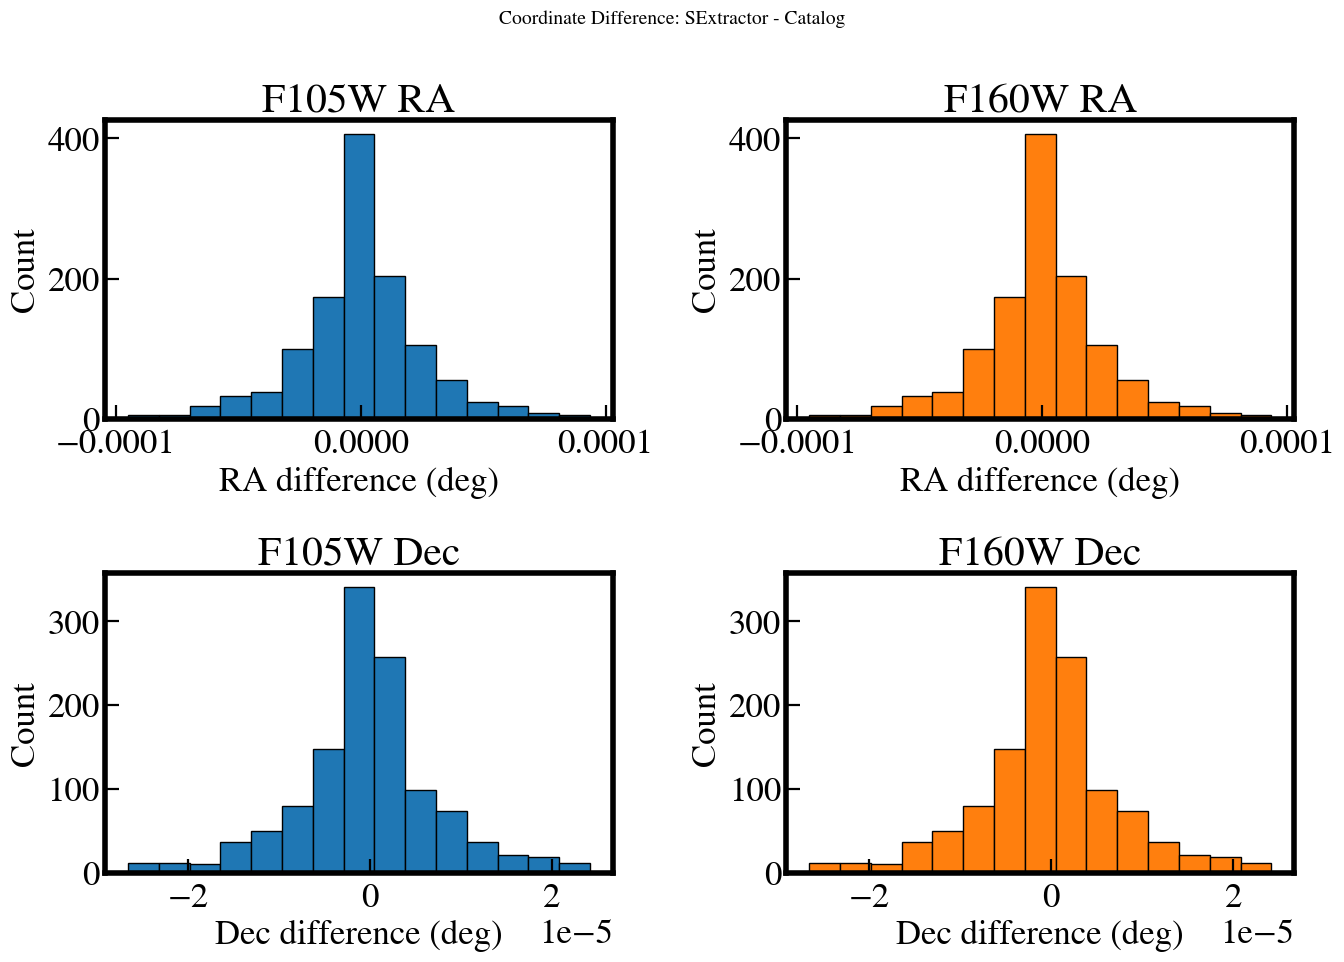

In [55]:
# =============================================================================
# RA/Dec Difference: SExtractor vs Catalog (Histogram)
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Coordinate Difference: SExtractor - Catalog', fontsize=14)

# F105W RA difference
ax[0, 0].hist(dat_0[idx_sex]['ra'] - dat_cat[idx_cat]['RA'], bins=15, color='tab:blue', edgecolor='black')
ax[0, 0].set_xlabel('RA difference (deg)')
ax[0, 0].set_ylabel('Count')
ax[0, 0].set_title(f'{bands[0]} RA')

# F160W RA difference
ax[0, 1].hist(dat_1[idx_sex]['ra'] - dat_cat[idx_cat]['RA'], bins=15, color='tab:orange', edgecolor='black')
ax[0, 1].set_xlabel('RA difference (deg)')
ax[0, 1].set_ylabel('Count')
ax[0, 1].set_title(f'{bands[1]} RA')

# F105W Dec difference
ax[1, 0].hist(dat_0[idx_sex]['dec'] - dat_cat[idx_cat]['Dec'], bins=15, color='tab:blue', edgecolor='black')
ax[1, 0].set_xlabel('Dec difference (deg)')
ax[1, 0].set_ylabel('Count')
ax[1, 0].set_title(f'{bands[0]} Dec')

# F160W Dec difference
ax[1, 1].hist(dat_1[idx_sex]['dec'] - dat_cat[idx_cat]['Dec'], bins=15, color='tab:orange', edgecolor='black')
ax[1, 1].set_xlabel('Dec difference (deg)')
ax[1, 1].set_ylabel('Count')
ax[1, 1].set_title(f'{bands[1]} Dec')

plt.tight_layout()
plt.show()


전부 0 또는 0과 비슷한 매우 비슷한 상수 중심의 narrowband에 정규분포인 것처럼 보이나..  dec은 종모양이 안나옴 문제가 있음 --> 이것도 pixel scale, 이랑 논문 input 값 비교 수정 후 개선


### (4) Catalog_unmatched property

In [56]:
# =============================================================================
# Find Catalog Unmatched Sources
# =============================================================================
# Get indices of catalog sources that were NOT matched to SExtractor
idx_cat_unmatched = np.setdiff1d(np.arange(len(dat_cat)), idx_cat)
dat_cat_unmatched = dat_cat[idx_cat_unmatched]

print(f"Catalog unmatched: {len(dat_cat_unmatched)}")
print(f"Catalog total: {len(dat_cat)}")
print(f"Catalog matched: {len(idx_cat)}")


Catalog unmatched: 274
Catalog total: 1475
Catalog matched: 1201


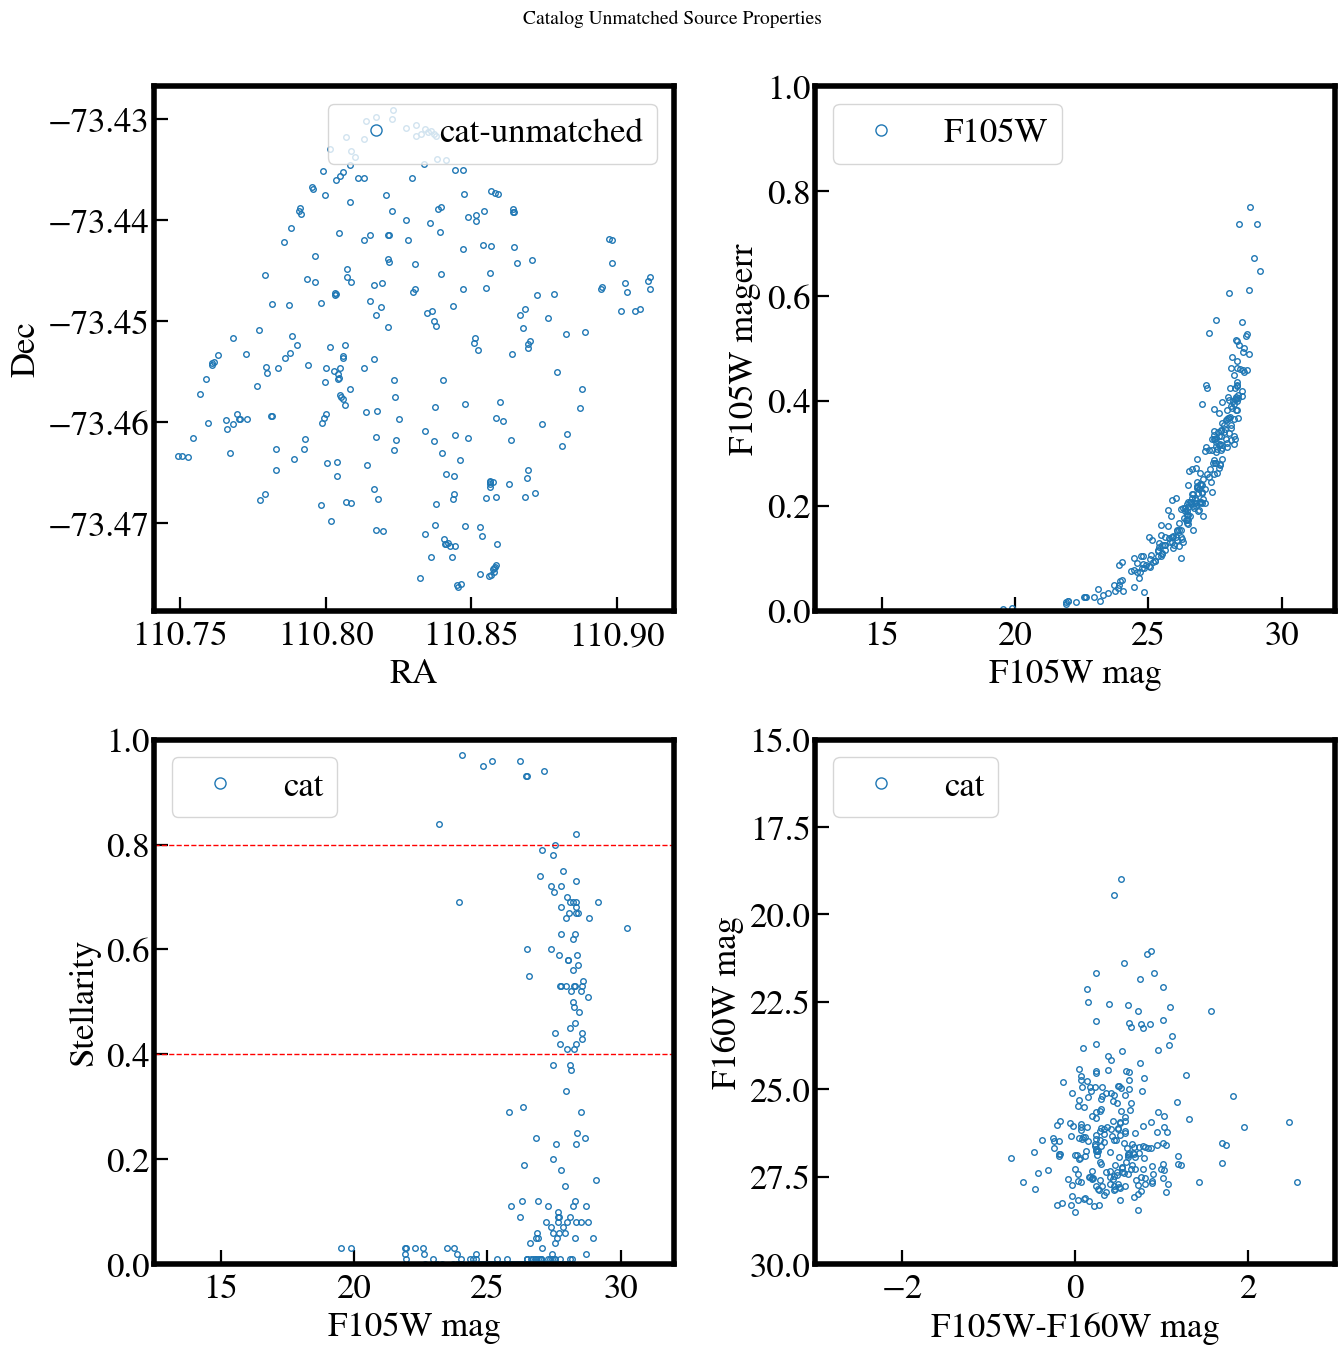

In [57]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Catalog Unmatched Source Properties
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('Catalog Unmatched Source Properties', fontsize=14)

# (0,0) RA/Dec
ax[0, 0].plot(dat_cat_unmatched['RA'], dat_cat_unmatched['Dec'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat-unmatched')
ax[0, 0].set_xlabel('RA')
ax[0, 0].set_ylabel('Dec')
ax[0, 0].legend(markerscale=2, handler_map=handler_map)

# (0,1) Mag-MagErr
ax[0, 1].plot(dat_cat_unmatched[f'{bands_catread[0]}_mag'], dat_cat_unmatched[f'{bands_catread[0]}_magerr'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0, 1].set_xlim([12.5, 32])
ax[0, 1].set_ylim([0, 1])
ax[0, 1].set_xlabel(f'{bands[0]} mag')
ax[0, 1].set_ylabel(f'{bands[0]} magerr')
ax[0, 1].legend(markerscale=2, handler_map=handler_map)

# (1,0) Mag-Stellarity
ax[1, 0].plot(dat_cat_unmatched[f'{bands_catread[0]}_mag'], dat_cat_unmatched['stel'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[1, 0].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[1, 0].axhline(0.8, 0, 1, color='red', ls='--', lw=1)
ax[1, 0].set_xlim([12.5, 32])
ax[1, 0].set_ylim([0.0, 1.0])
ax[1, 0].set_xlabel(f'{bands[0]} mag')
ax[1, 0].set_ylabel('Stellarity')
ax[1, 0].legend(markerscale=2, handler_map=handler_map)

# (1,1) CMD
ax[1, 1].plot(dat_cat_unmatched[f'{bands_catread[0]}_mag'] - dat_cat_unmatched[f'{bands_catread[1]}_mag'],
              dat_cat_unmatched[f'{bands_catread[1]}_mag'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat')
ax[1, 1].set_xlim([-3, 3])
ax[1, 1].set_ylim([30, 15])
ax[1, 1].set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax[1, 1].set_ylabel(f'{bands[1]} mag')
ax[1, 1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


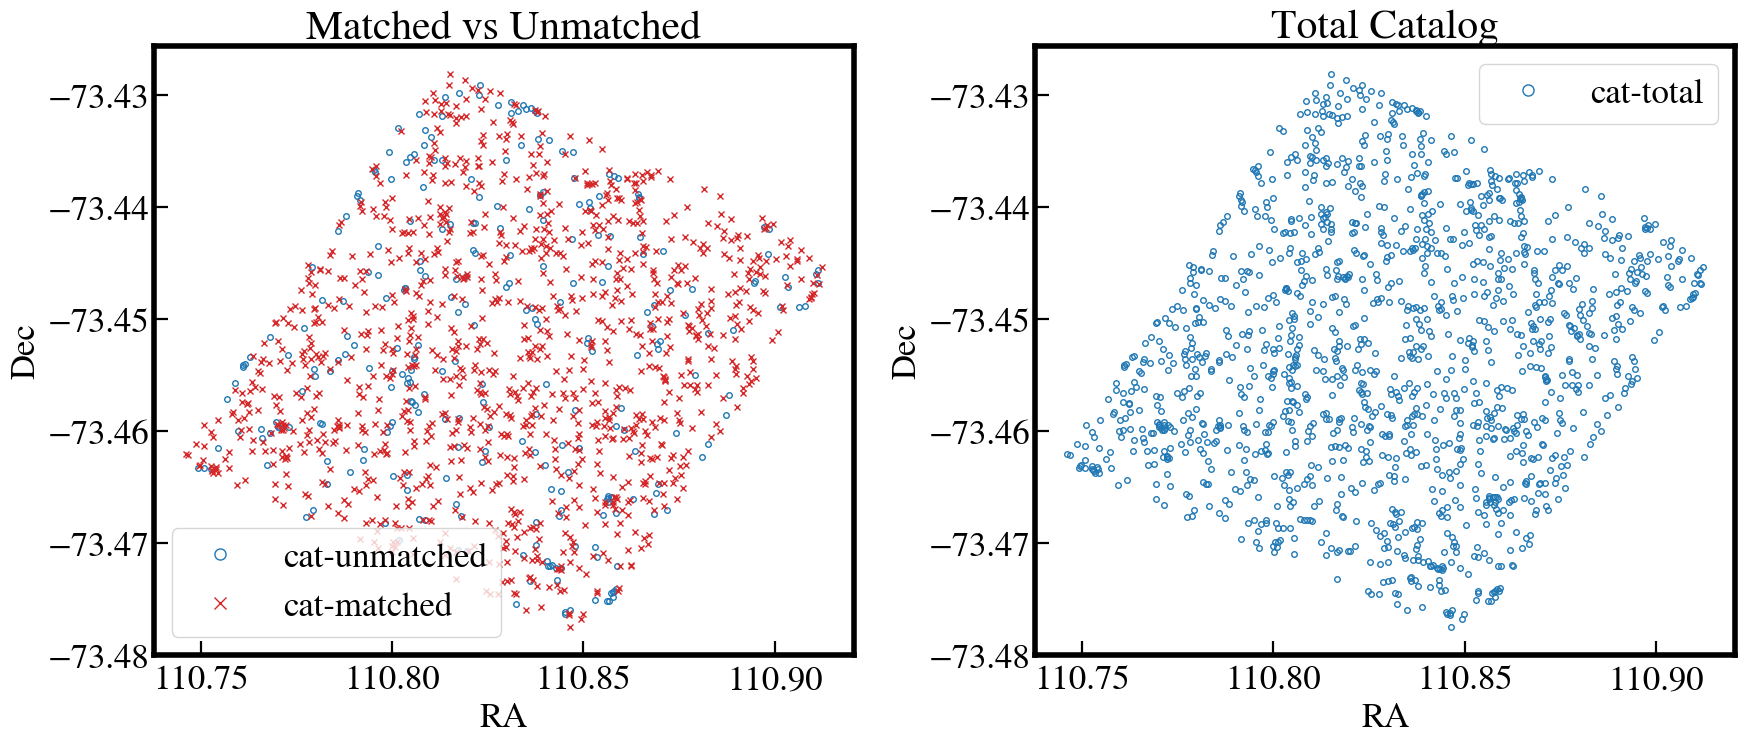

In [58]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Catalog: Matched vs Unmatched Position Comparison
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: matched vs unmatched
ax[0].plot(dat_cat_unmatched['RA'], dat_cat_unmatched['Dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat-unmatched')
ax[0].plot(dat_cat[idx_cat]['RA'], dat_cat[idx_cat]['Dec'],
           marker='x', ms=4, color='tab:red', linestyle='None', label='cat-matched')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('Dec')
ax[0].set_title('Matched vs Unmatched')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: total catalog
ax[1].plot(dat_cat['RA'], dat_cat['Dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='cat-total')
ax[1].set_xlabel('RA')
ax[1].set_ylabel('Dec')
ax[1].set_title('Total Catalog')
ax[1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


### (5) SExtractor Output_unmatched property

In [59]:
# =============================================================================
# Find SExtractor Unmatched Sources
# =============================================================================
# Get indices of SExtractor sources that were NOT matched to catalog
idx_sex_unmatched = np.setdiff1d(np.arange(len(dat_0)), idx_sex)
dat_0_unmatched = dat_0[idx_sex_unmatched]
dat_1_unmatched = dat_1[idx_sex_unmatched]

print(f"SExtractor unmatched: {len(dat_0_unmatched)}")
print(f"SExtractor total: {len(dat_0)}")
print(f"SExtractor matched: {len(idx_sex)}")


SExtractor unmatched: 1282
SExtractor total: 2483
SExtractor matched: 1201


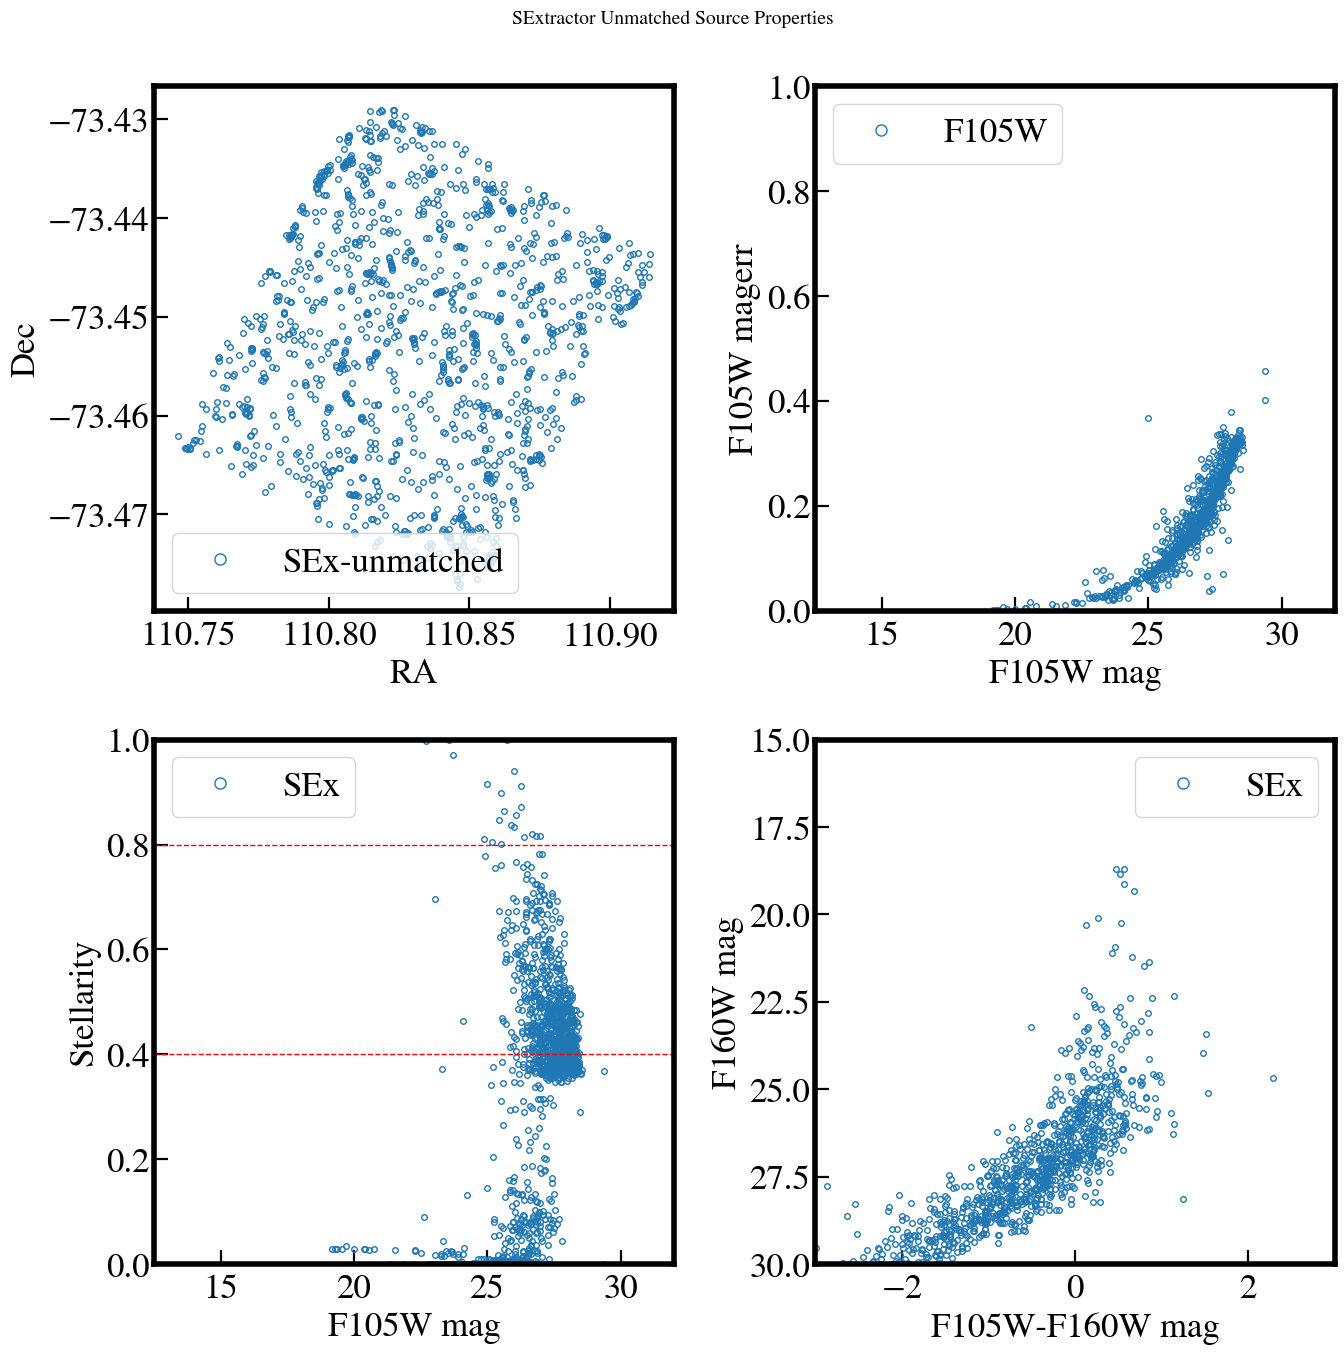

In [60]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# SExtractor Unmatched Source Properties
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('SExtractor Unmatched Source Properties', fontsize=14)

# (0,0) RA/Dec
ax[0, 0].plot(dat_0_unmatched['ra'], dat_0_unmatched['dec'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx-unmatched')
ax[0, 0].set_xlabel('RA')
ax[0, 0].set_ylabel('Dec')
ax[0, 0].legend(markerscale=2, handler_map=handler_map)

# (0,1) Mag-MagErr
ax[0, 1].plot(dat_0_unmatched['mag_iso'], dat_0_unmatched['magerr_iso'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0, 1].set_xlim([12.5, 32])
ax[0, 1].set_ylim([0, 1])
ax[0, 1].set_xlabel(f'{bands[0]} mag')
ax[0, 1].set_ylabel(f'{bands[0]} magerr')
ax[0, 1].legend(markerscale=2, handler_map=handler_map)

# (1,0) Mag-Stellarity
ax[1, 0].plot(dat_0_unmatched['mag_iso'], dat_0_unmatched['cl'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx')
ax[1, 0].axhline(0.4, 0, 1, color='red', ls='--', lw=1)
ax[1, 0].axhline(0.8, 0, 1, color='red', ls='--', lw=1)
ax[1, 0].set_xlim([12.5, 32])
ax[1, 0].set_ylim([0.0, 1.0])
ax[1, 0].set_xlabel(f'{bands[0]} mag')
ax[1, 0].set_ylabel('Stellarity')
ax[1, 0].legend(markerscale=2, handler_map=handler_map)

# (1,1) CMD
ax[1, 1].plot(dat_0_unmatched['mag_iso'] - dat_1_unmatched['mag_iso'],
              dat_1_unmatched['mag_iso'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx')
ax[1, 1].set_xlim([-3, 3])
ax[1, 1].set_ylim([30, 15])
ax[1, 1].set_xlabel(f'{bands[0]}-{bands[1]} mag')
ax[1, 1].set_ylabel(f'{bands[1]} mag')
ax[1, 1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


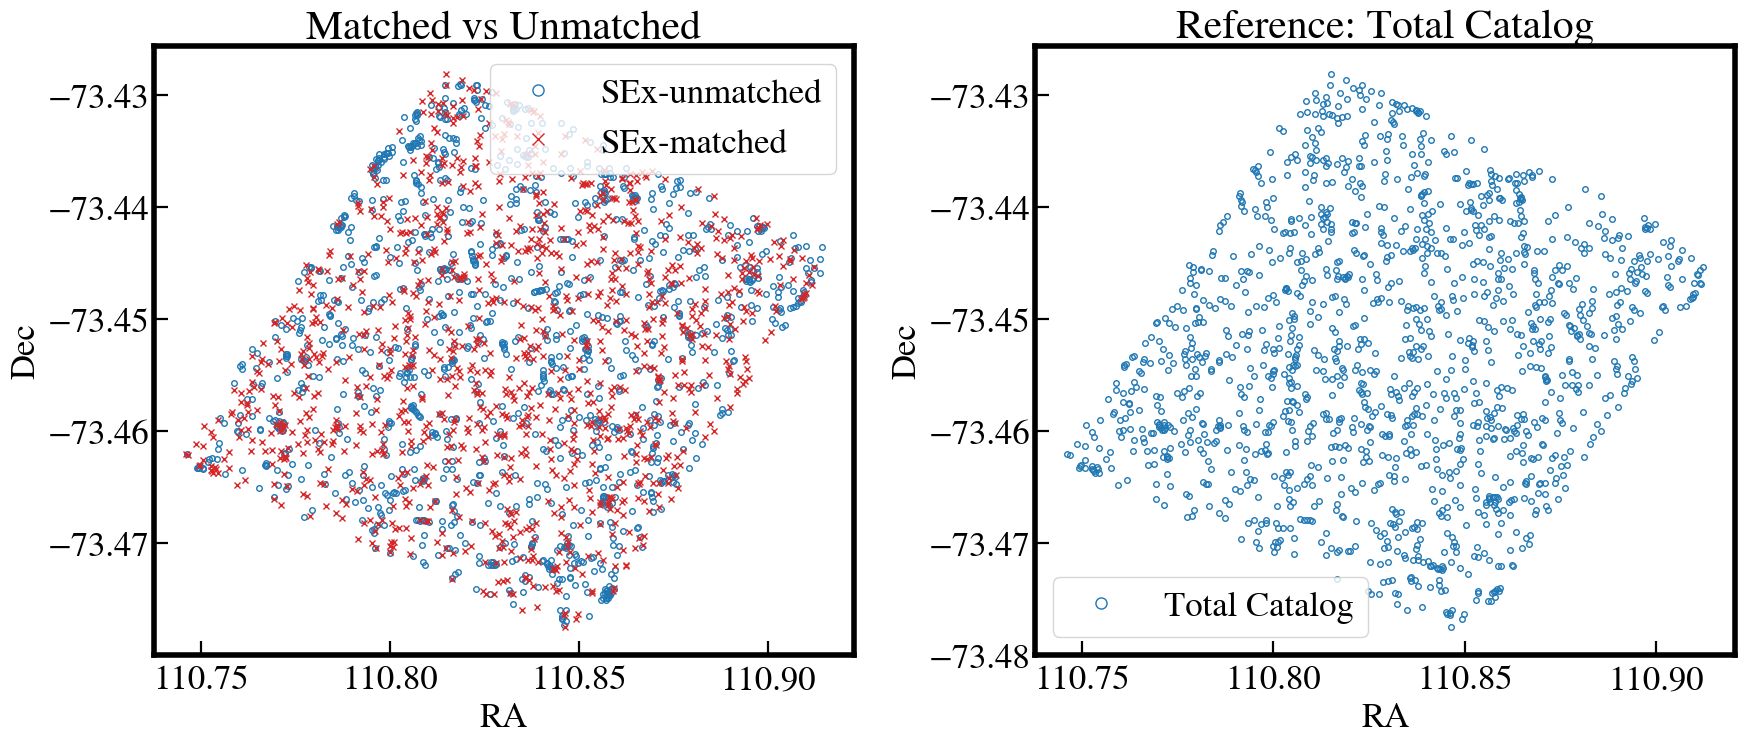

In [61]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# SExtractor: Matched vs Unmatched Position Comparison
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: matched vs unmatched
ax[0].plot(dat_0_unmatched['ra'], dat_0_unmatched['dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='SEx-unmatched')
ax[0].plot(dat_0[idx_sex]['ra'], dat_0[idx_sex]['dec'],
           marker='x', ms=4, color='tab:red', linestyle='None', label='SEx-matched')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('Dec')
ax[0].set_title('Matched vs Unmatched')
ax[0].legend(markerscale=2, handler_map=handler_map)

# Right panel: total catalog for reference
ax[1].plot(dat_cat['RA'], dat_cat['Dec'],
           marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='Total Catalog')
ax[1].set_xlabel('RA')
ax[1].set_ylabel('Dec')
ax[1].set_title('Reference: Total Catalog')
ax[1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()
